# **ARREGLAMOS EL INVENTARIO FINAL**

## Pasar archivo .xlsx a .csv

In [8]:
# Convert the uploaded Excel to two CSV variants handling decimal commas in lat/lon.
import pandas as pd
import numpy as np
from pathlib import Path

input_file = Path("../../data/processed/INVENTARIO_FECHA_UBICACION.xlsx")
df = pd.read_excel(input_file, sheet_name="Hoja 2")


# Try to detect latitude/longitude columns
cols_lower = {c.lower(): c for c in df.columns}
lat_candidates = [c for c in df.columns if "lat" in c.lower() or "latitud" in c.lower()]
lon_candidates = [c for c in df.columns if "lon" in c.lower() or "longitud" in c.lower()]

lat_col = lat_candidates[0] if len(lat_candidates) else None
lon_col = lon_candidates[0] if len(lon_candidates) else None

# Normalize decimal commas in detected lat/lon (convert to decimal point for numeric consistency)
for col in [lat_col, lon_col]:
    if col and df[col].dtype == object:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.replace("\u00a0", "", regex=False)   # non-breaking space
            .str.replace(" ", "", regex=False)        # spaces
            .str.replace(",", ".", regex=False)       # decimal comma -> decimal point
        )
    if col:
        # Try to coerce to numeric (invalid parsing becomes NaN)
        df[col] = pd.to_numeric(df[col], errors="coerce")


# Save two CSV versions:
# 1) Standard (US-style): comma separator, decimal point
csv_us = Path("../../data/processed/INVENTARIO_FECHA_UBICACION.csv")
df.to_csv(csv_us, index=False, sep=",", decimal=".")



## Unir dos tablas del inventario

In [9]:

#!/usr/bin/env python3
import pandas as pd

inventario_1 = pd.read_csv('../../data/processed/INVENTARIO_FECHA_UBICACION.csv')
inventario_2 = pd.read_csv('../../data/processed/inventario_20251103.csv')

print(inventario_1.columns)
print(inventario_2.columns)

Index(['ID', 'latitud', 'longitud', 'incer_ubicacion', 'fecha_hora',
       'incer_fecha', 'incer_hora', 'tipo', 'municipio', 'corregimiento',
       'vereda_barrio', 'Pluvio', 'Acum', 'I', 'Duracion', 'Radar',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18'],
      dtype='object')
Index(['fecha_hora_evento', 'incertidumbre_fecha', 'latitud', 'longitud',
       'incertidumbre_ubicacion', 'tipo_movimiento_masa', 'municipio',
       'corregimiento', 'vereda_barrio', 'Codigo',
       ...
       '88d', '89d', '90d', '91d', '92d', '93d', '94d', '95d', '96d', '97d'],
      dtype='object', length=108)


In [ ]:
import pandas as pd
import re

# 1) Carga
inventario_1 = pd.read_csv('../../data/processed/INVENTARIO_FECHA_UBICACION.csv')
inventario_2 = pd.read_csv('../../data/processed/inventario_20251103.csv')

# 2) Renombrar columnas de inventario_1 para que coincidan con el esquema de inventario_2
mapa_cols = {
    'fecha_hora': 'fecha_hora_evento',
    'incer_ubicacion': 'incertidumbre_ubicacion',
    'incer_fecha': 'incertidumbre_fecha',
    'tipo': 'tipo_movimiento_masa',
    'Pluvio': 'Codigo',
    # las siguientes ya coinciden: 'latitud', 'longitud', 'municipio', 'corregimiento', 'vereda_barrio'
}
inv1 = inventario_1.rename(columns=mapa_cols).copy()

# 3) Limpiar columnas no deseadas de inventario_1 (ID y Unnamed)
inv1 = inv1.loc[:, ~inv1.columns.str.startswith('Unnamed')]
inv1 = inv1.drop(columns=['ID'], errors='ignore')

# 4) Determinar columnas a conservar según la segunda tabla,
#    excluyendo acumulados diarios tipo "1d", "2d", ..., "97d"
pat_acum = re.compile(r'^\s*\d+\s*d\s*$', flags=re.IGNORECASE)
cols_objetivo = [c for c in inventario_2.columns if not pat_acum.match(str(c))]

# 5) Proyectar ambos DataFrames al mismo esquema (las que existan en cada uno)
inv1 = inv1[[c for c in cols_objetivo if c in inv1.columns]].copy()
inv2 = inventario_2[[c for c in cols_objetivo if c in inventario_2.columns]].copy()

# 6) Reindexar para alinear orden/ausentes
inv1 = inv1.reindex(columns=cols_objetivo)
inv2 = inv2.reindex(columns=cols_objetivo)

# 7) Concatenar poniendo PRIMERO inv1 (para que drop_duplicates conserve los de inv1)
unido = pd.concat([inv1, inv2], ignore_index=True)

# 8) (Opcional pero recomendable) eliminar filas sin coordenadas antes de deduplicar
unido = unido.dropna(subset=['latitud', 'longitud'])

# 9) Quitar duplicados por (latitud, longitud) conservando la PRIMERA aparición (la de inv1)
unido = unido.drop_duplicates(subset=['latitud', 'longitud', 'fecha_hora_evento'], keep='first')


# 10) Agregar columna "si_no" con valor 1 en todas las filas
unido['si_no'] = 1

# 10) Guardar
salida = '../../data/processed/inventario_unificado.csv'
unido.to_csv(salida, index=False)
print(f'Listo. Filas: {len(unido)}  |  Columnas: {len(unido.columns)}  |  Archivo: {salida}')


Listo. Filas: 496  |  Columnas: 11  |  Archivo: ../../data/processed/inventario_unificado.csv


In [14]:
import re
import unicodedata
import pandas as pd

def _strip_accents(s: str) -> str:
    # (opcional) normaliza acentos si hubiera variantes raras; no cambia las letras, solo facilita matches
    if not isinstance(s, str):
        return s
    return ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c))

def normalizar_tipo_mm(s: str) -> str:
    """
    Normaliza nombres en 'tipo_movimiento_masa':
      - recorta espacios
      - pasa a minúsculas
      - unifica separadores ('-', '_') a espacio simple
      - mapea equivalencias (traslacional-complejo -> traslacional)
      - capitaliza solo la primera letra del resultado
    """
    if pd.isna(s):
        return s
    # texto base
    txt = str(s).strip()
    txt = _strip_accents(txt)  # opcional
    txt = txt.lower()

    # unificar separadores y espacios múltiples
    txt = re.sub(r'[-_]+', ' ', txt)   # 'traslacional-complejo' -> 'traslacional complejo'
    txt = re.sub(r'\s+', ' ', txt).strip()

    # mapa de equivalencias (extiéndelo según necesites)
    equivalencias = {
        'traslacional complejo': 'traslacional',
        'traslacional-complejo': 'traslacional',  # por si acaso antes de reemplazos
        'deslizamiento': 'deslizamiento',
        'flujo': 'flujo',
        # agrega aquí más sinónimos: 'caida de rocas':'caida de rocas', etc.
    }

    # aplicar equivalencias si coincide exacto
    if txt in equivalencias:
        txt = equivalencias[txt]

    # capitalizar solo la primera letra del string completo
    if txt:
        txt = txt[0].upper() + txt[1:]

    return txt

# Aplicar al DataFrame (usa tu df si no es 'unido')
unido['tipo_movimiento_masa'] = unido['tipo_movimiento_masa'].apply(normalizar_tipo_mm)

# (Opcional) verifica el resultado
print(unido['tipo_movimiento_masa'].value_counts(dropna=False).head(20))


tipo_movimiento_masa
Deslizamiento     349
Flujo             107
Otro               19
Caida de rocas      8
NaN                 6
Complejo            5
Traslacional        2
Name: count, dtype: int64


In [19]:
import pandas as pd
import numpy as np
import re

# Cargar
inventario = pd.read_csv('../../data/processed/inventario_unificado.csv')

# 1) Limpieza ligera del texto (por si hay NBSP u otros espacios raros)
s = (
    inventario['fecha_hora_evento']
    .astype(str).str.strip()
    .str.replace('\u00a0', ' ', regex=False)  # NBSP -> espacio normal
    .str.replace(r'\s+', ' ', regex=True)     # colapsar espacios
)

# 2) Parseo robusto:
#    - Intento 1: pandas>=2.0 con format='mixed'
#    - Si no existe (TypeError), usamos dos pasadas (dayfirst False y True)
try:
    dt = pd.to_datetime(s, format='mixed', errors='coerce')   # pandas >= 2.0
except TypeError:
    # Fallback compatible: dos intentos con dayfirst distintos
    dt = pd.to_datetime(s, errors='coerce', dayfirst=False)
    faltan = dt.isna()
    if faltan.any():
        dt2 = pd.to_datetime(s[faltan], errors='coerce', dayfirst=True)
        dt.loc[faltan] = dt2

# (Opcional) Reportar cuántas no se pudieron parsear
n_nat = dt.isna().sum()
print(f'No se pudieron parsear: {n_nat} filas')

# 3) Formatear a la cadena exacta "%Y-%m-%d %H:%M:%S"
#    Nota: strftime devuelve STRING; si quieres conservar el dtype datetime, guarda otra columna.
inventario['fecha_hora_evento_dt'] = dt  # conservar versión datetime (útil para análisis)
inventario['fecha_hora_evento'] = dt.dt.strftime('%Y-%m-%d %H:%M:%S')

# 4) (Opcional) Filas problemáticas para revisar manualmente
if n_nat > 0:
    problem = inventario.loc[inventario['fecha_hora_evento_dt'].isna(), ['fecha_hora_evento']]
    print('Ejemplos problemáticos:')
    print(problem.head(10))

inventario = inventario.drop(columns=['fecha_hora_evento_dt'], errors='ignore')

# 5) Guardar si quieres persistir el formato uniforme
inventario.to_csv('../../data/processed/inventario_unificado.csv', index=False)
print('Fechas uniformadas y archivo guardado.')


No se pudieron parsear: 0 filas
Fechas uniformadas y archivo guardado.


/tmp/ipykernel_66262/257412897.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tipo_frecuencia.index, y=tipo_frecuencia.values,


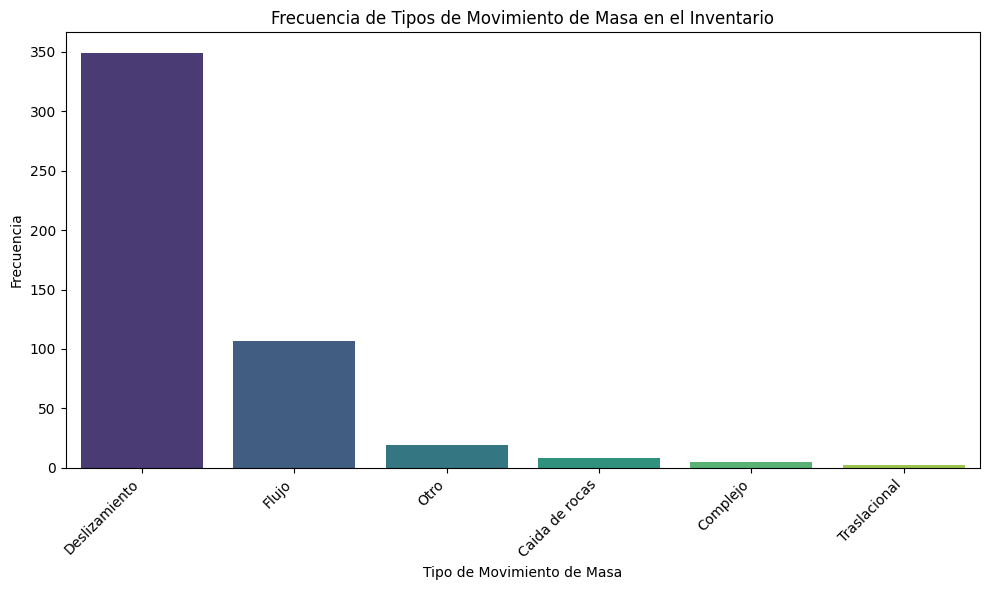

In [16]:
#hacer un grafico de barras con los tipos de movimiento de masa y su frecuencia
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
inventario = pd.read_csv('../../data/processed/inventario_unificado.csv')
tipo_frecuencia = inventario['tipo_movimiento_masa'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=tipo_frecuencia.index, y=tipo_frecuencia.values,
            palette='viridis')
plt.xlabel('Tipo de Movimiento de Masa')
plt.ylabel('Frecuencia')
plt.title('Frecuencia de Tipos de Movimiento de Masa en el Inventario')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_66262/427496434.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=municipio_frecuencia.index, y=municipio_frecuencia.values,


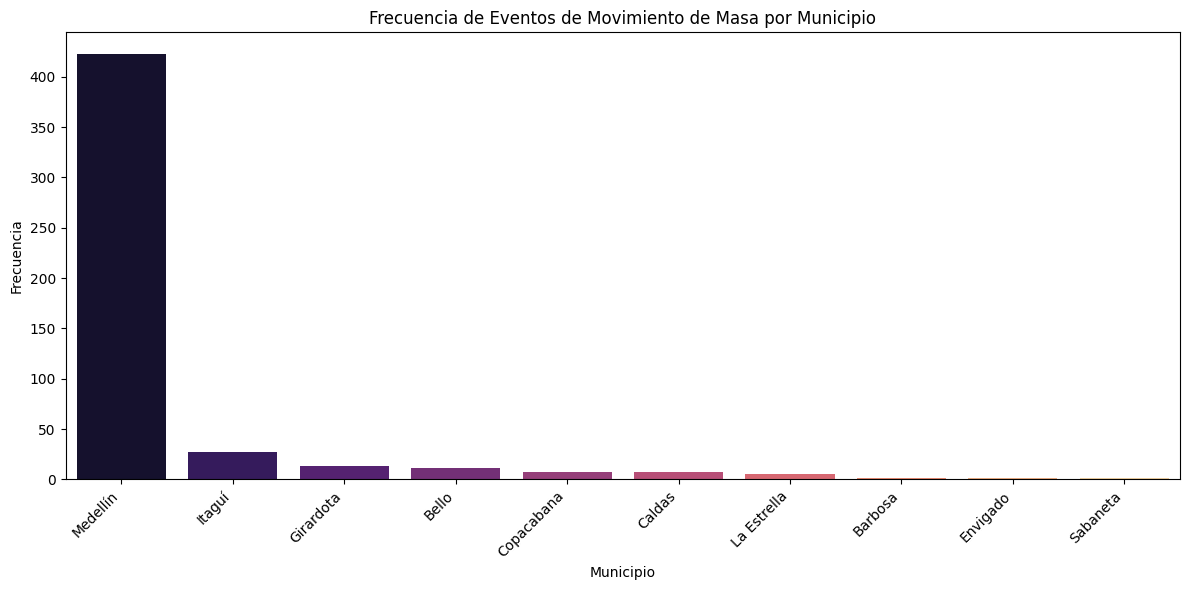

In [17]:
#hacerun grafico de barras con los municipios y su frecuencia de eventos de movimiento de masa
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
inventario = pd.read_csv('../../data/processed/inventario_unificado.csv')
municipio_frecuencia = inventario['municipio'].value_counts()
plt.figure(figsize=(12,6))
sns.barplot(x=municipio_frecuencia.index, y=municipio_frecuencia.values,
            palette='magma')
plt.xlabel('Municipio')
plt.ylabel('Frecuencia')
plt.title('Frecuencia de Eventos de Movimiento de Masa por Municipio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

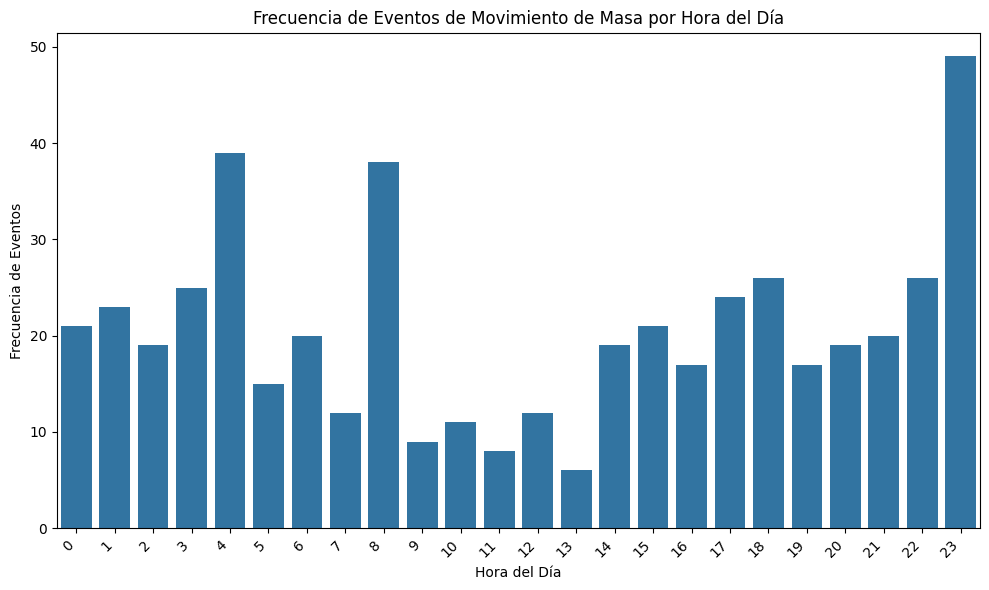

In [23]:
#hacer ungraficoquemuestre las horas del dia en que ocurren mas eventos de movimiento de masa
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
inventario = pd.read_csv('../../data/processed/inventario_unificado.csv')
inventario['hora_evento'] = pd.to_datetime(inventario['fecha_hora_evento']).dt.hour
hora_frecuencia = inventario['hora_evento'].value_counts().sort_index()
plt.figure(figsize=(10,6))
sns.barplot(x=hora_frecuencia.index, y=hora_frecuencia.values)
plt.xlabel('Hora del Día')
plt.ylabel('Frecuencia de Eventos')
plt.title('Frecuencia de Eventos de Movimiento de Masa por Hora del Día')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

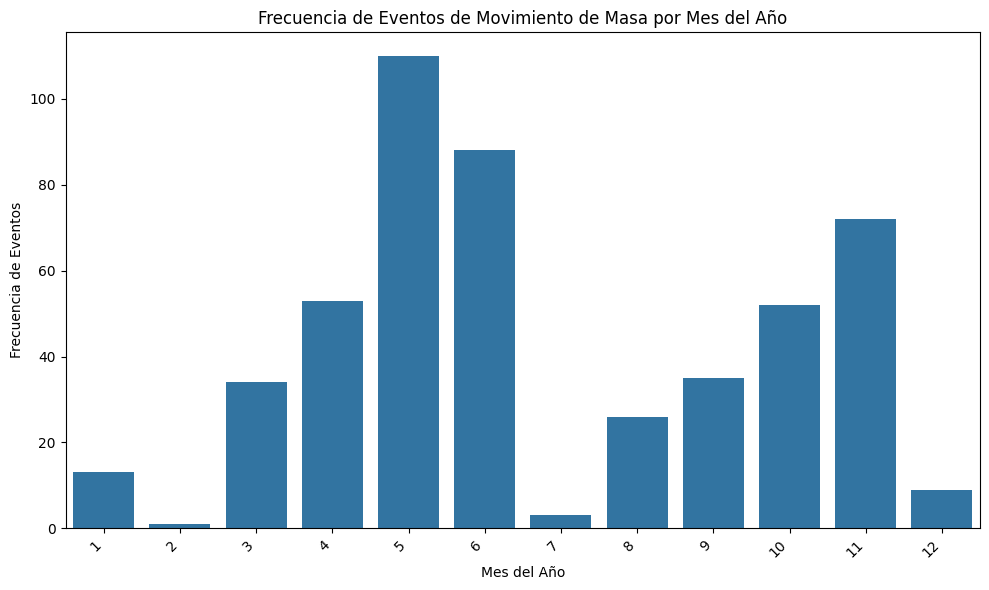

In [22]:
#hacer un grafico  de barras con  los meses del año en que ocurren mas eventos de movimiento de masa
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
inventario = pd.read_csv('../../data/processed/inventario_unificado.csv')
inventario['mes_evento'] = pd.to_datetime(inventario['fecha_hora_evento']).dt.month
mes_frecuencia = inventario['mes_evento'].value_counts().sort_index()
plt.figure(figsize=(10,6))
sns.barplot(x=mes_frecuencia.index, y=mes_frecuencia.values)
plt.xlabel('Mes del Año')
plt.ylabel('Frecuencia de Eventos')
plt.title('Frecuencia de Eventos de Movimiento de Masa por Mes del Año')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

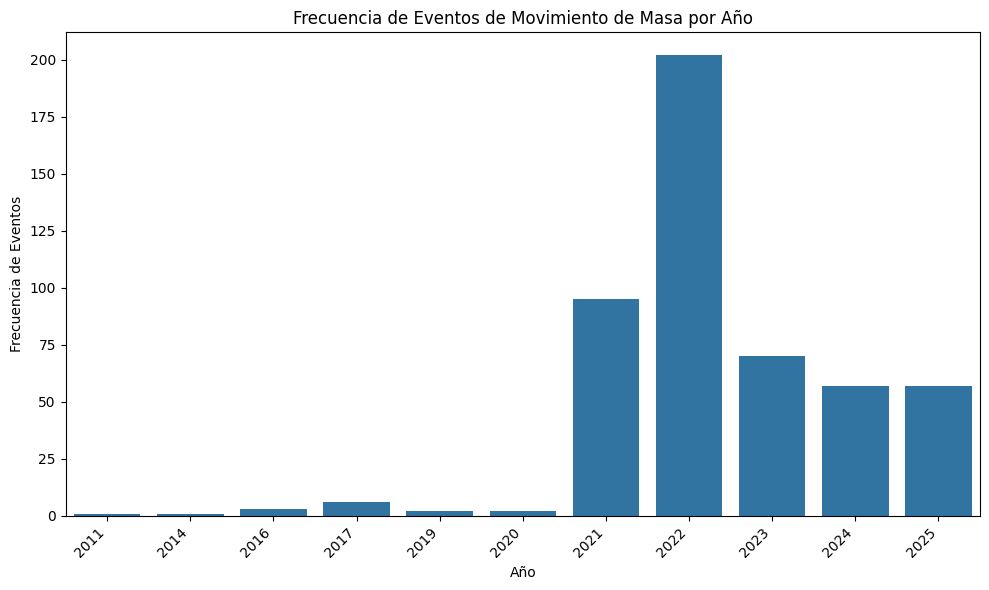

In [24]:
#hacer  un grafico de barras con los años en que ocurren mas eventos de movimiento de masa
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
inventario = pd.read_csv('../../data/processed/inventario_unificado.csv')
inventario['año_evento'] = pd.to_datetime(inventario['fecha_hora_evento']).dt.year
año_frecuencia = inventario['año_evento'].value_counts().sort_index()
plt.figure(figsize=(10,6))
sns.barplot(x=año_frecuencia.index, y=año_frecuencia.values)
plt.xlabel('Año')
plt.ylabel('Frecuencia de Eventos')
plt.title('Frecuencia de Eventos de Movimiento de Masa por Año')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Actualización de Slope Units con inventario de deslizamientos (CSV de puntos)
# - Autor: tú :)
# - Requisitos: geopandas, pandas, shapely, pyproj (GeoPandas stack)
# - Resultado:
#     * su_updated: GeoDataFrame de Slope Units con si_no/n_mm actualizados y columnas heredadas
#     * su_eventos: tabla relacional (one-to-many) con cada punto asignado a su SU


In [10]:
import pandas as pd
import geopandas as gpd

slope_unit_paths = '/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/slope_units_analisis.shp'

slope_unit = gpd.read_file(slope_unit_paths)

inventario = pd.read_csv('../../data/processed/inventario_unificado.csv')

In [11]:
inventario.columns

Index(['fecha_hora_evento', 'incertidumbre_fecha', 'latitud', 'longitud',
       'incertidumbre_ubicacion', 'tipo_movimiento_masa', 'municipio',
       'corregimiento', 'vereda_barrio', 'Codigo', 'si_no'],
      dtype='object')

In [8]:
slope_unit.columns

Index(['index', 'slope_mean', 'aspect_maj', 'flowacum_m', 'tpi_mean',
       'ugs_majo', 'twi_mean', 'mm', 'area', 'curvatura', 'cobertura',
       'cluster4', 'su_idx', 'zona', 'n_mm', 'si_no', 'geometry'],
      dtype='object')

## Actualización de Slope Units con inventario de deslizamientos (CSV de puntos)
 - Resultado:
     * su_updated: GeoDataFrame de Slope Units con si_no/n_mm actualizados y columnas heredadas
     * su_eventos: tabla relacional (one-to-many) con cada punto asignado a su SU (geometría de punto)
     * su_slope_units_eventos: GeoDataFrame con una fila por deslizamiento y geometría de Slope Unit (GeoJSON)


In [6]:

# %%
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point

# === 1) Rutas de entrada/salida ===
slope_units_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/slope_units_analisis.shp"
inventario_csv    = "../../data/processed/inventario_unificado.csv"

# Salida principal (como antes, en GPKG)
salida_gpkg       = "/home/oisanchezp/Thesis/data/raw/slope_units_analisis_actualizado.gpkg"
capa_poligonos    = "slope_units_actualizadas"
capa_relacional   = "su_eventos"

# NUEVA salida GeoJSON: una fila por deslizamiento con geometría de la Slope Unit
salida_geojson    = "/home/oisanchezp/Thesis/data/raw/slope_units_eventos.geojson"

# === 2) Leer capas ===
su = gpd.read_file(slope_units_path)

# Asegurar tipos en si_no y n_mm
if "si_no" not in su.columns:
    raise ValueError("La capa de Slope Units no tiene columna 'si_no'.")
if "n_mm" not in su.columns:
    su["n_mm"] = 0

su["si_no"] = pd.to_numeric(su["si_no"], errors="coerce").fillna(0).astype(int)
su["n_mm"]  = pd.to_numeric(su["n_mm"],  errors="coerce").fillna(0).astype(int)

# Comprobación de identificador único de SU
su_id_col = "su_idx" if "su_idx" in su.columns else "index"
if su_id_col not in su.columns:
    raise ValueError("No se encontró 'su_idx' ni 'index' en Slope Units. Necesito un ID para unir.")

# Leer inventario
inv = pd.read_csv(inventario_csv)

# Columnas esperadas del inventario
cols_inv = [
    "fecha_hora_evento", "incertidumbre_fecha", "latitud", "longitud",
    "incertidumbre_ubicacion", "tipo_movimiento_masa", "municipio",
    "corregimiento", "vereda_barrio", "Codigo", "si_no"
]
faltantes = [c for c in cols_inv if c not in inv.columns]
if faltantes:
    raise ValueError(f"Al inventario le faltan columnas: {faltantes}")

# === 3) Limpiar inventario (NaN, tipos, duplicados por Codigo) ===
inv = inv.copy()
inv["latitud"] = pd.to_numeric(inv["latitud"], errors="coerce")
inv["longitud"] = pd.to_numeric(inv["longitud"], errors="coerce")


# === 4) GeoDataFrame de inventario y CRS ===
inv_gdf = gpd.GeoDataFrame(
    inv,
    geometry=gpd.points_from_xy(inv["longitud"], inv["latitud"]),
    crs="EPSG:4326"
)

# Asegurar que SU tiene CRS
if su.crs is None:
    raise ValueError("La capa de Slope Units no tiene CRS. Asigna su CRS antes de continuar (su.set_crs(...)).")

# Proyectar inventario al CRS de SU
inv_gdf = inv_gdf.to_crs(su.crs)

# === 5) Cruce espacial (punto en polígono) ===
su_min = su[[su_id_col, "geometry"]].copy()
join = gpd.sjoin(inv_gdf, su_min, how="inner", predicate="within")
# join: columnas del inventario + columna su_id_col (ID de SU) + geometry (punto)

# === 6) Tabla relacional SU–evento (geometría de punto, como antes) ===
su_eventos = join[[su_id_col] + cols_inv + ["geometry"]].copy()

# === 7) Agregación por SU para actualizar si_no y n_mm a nivel de Slope Unit ===
conteo = join.groupby(su_id_col).size().rename("new_mm").to_frame()

# Columnas a heredar (concatenadas) a nivel de SU
cols_heredar = [
    "fecha_hora_evento", "incertidumbre_fecha", "latitud", "longitud",
    "incertidumbre_ubicacion", "tipo_movimiento_masa", "municipio",
    "corregimiento", "vereda_barrio", "Codigo"
]

def _concat_unique(series):
    vals = pd.unique(series.dropna())
    return "; ".join(map(str, vals)) if len(vals) > 0 else np.nan

agg_funcs = {c: _concat_unique for c in cols_heredar}
agg_cols = join.groupby(su_id_col).agg(agg_funcs)

agg_su = conteo.join(agg_cols, how="left").reset_index()

# === 8) Mezclar con Slope Units y aplicar reglas de actualización ===
su_updated = su.merge(agg_su, on=su_id_col, how="left")

su_updated["new_mm"] = pd.to_numeric(su_updated["new_mm"], errors="coerce").fillna(0).astype(int)

# Regla 1: si si_no==0 y hay >=1 nuevos -> poner 1; si ya era 1, no cambiar
su_updated["si_no"] = np.where(
    (su_updated["si_no"] == 0) & (su_updated["new_mm"] > 0),
    1,
    su_updated["si_no"]
)

# Regla 2: sumar nuevos deslizamientos a n_mm
su_updated["n_mm"] = (
    pd.to_numeric(su_updated["n_mm"], errors="coerce").fillna(0).astype(int)
    + su_updated["new_mm"]
)

# (Opcional) dejar columnas heredadas solo cuando haya eventos
for c in cols_heredar:
    su_updated.loc[su_updated["new_mm"] == 0, c] = su_updated.loc[su_updated["new_mm"] == 0, c]

# === 9) Guardar resultados en GPKG (como antes) ===
su_updated.to_file(salida_gpkg, layer=capa_poligonos, driver="GPKG")
su_eventos.to_file(salida_gpkg, layer=capa_relacional, driver="GPKG")

print("Listo ✅")
print(f"- Polígonos actualizados: {salida_gpkg} (capa: {capa_poligonos})")
print(f"- Tabla SU–eventos (puntos): {salida_gpkg} (capa: {capa_relacional})")




Listo ✅
- Polígonos actualizados: /home/oisanchezp/Thesis/data/raw/slope_units_analisis_actualizado.gpkg (capa: slope_units_actualizadas)
- Tabla SU–eventos (puntos): /home/oisanchezp/Thesis/data/raw/slope_units_analisis_actualizado.gpkg (capa: su_eventos)


In [7]:
# === 10) NUEVA capa: Slope Units + eventos (una fila por deslizamiento, geometría de SU) ===
# Queremos quedarnos solo con estas columnas de la SU
su_cols_keep_base = ["index", "cluster4", "su_idx", "zona", "n_mm", "si_no", "geometry"]

# Nos quedamos con las que existan, PERO excluimos la columna usada como ID (su_id_col)
su_cols_keep = [
    c for c in su_cols_keep_base
    if c in su_updated.columns and c != su_id_col
]

# Tabla de eventos con ID de SU + columnas del inventario
eventos_su = join[[su_id_col] + cols_inv].copy()

# Evitar conflicto de nombre entre si_no de la SU y si_no del inventario
eventos_su = eventos_su.rename(columns={"si_no": "si_no_evento"})

# Subconjunto de SU actualizado con solo las columnas deseadas
su_min_geojson = su_updated[[su_id_col] + su_cols_keep].copy()

# Merge: una fila por deslizamiento con geometría y atributos de la SU
su_slope_units_eventos = eventos_su.merge(su_min_geojson, on=su_id_col, how="left")

su_slope_units_eventos = gpd.GeoDataFrame(
    su_slope_units_eventos,
    geometry="geometry",
    crs=su_updated.crs
)

su_slope_units_eventos.to_file(salida_geojson, driver="GeoJSON")
print(f"- Capa SU+eventos (GeoJSON, una fila por deslizamiento): {salida_geojson}")


- Capa SU+eventos (GeoJSON, una fila por deslizamiento): /home/oisanchezp/Thesis/data/raw/slope_units_eventos.geojson
